#8. Семантический поиск и RAG


---

## Содержание

1. Введение в семантический поиск
2. Разбиение текста на фрагменты (Chunking)
3. Лексический поиск: BM25
4. Плотные векторные представления (Dense Embeddings)
5. Визуализация эмбеддингов
6. Векторный поиск с FAISS
7. Кросс-энкодер для переранжирования
8. RAG: поиск + генерация
9. Полноценный RAG-конвейер
10. Самостоятельные задания

## 1. Введение в семантический поиск

Классический (лексический) поиск ищет совпадения ключевых слов.
Семантический поиск находит документы, близкие по смыслу, даже если
они используют другие слова.

Два подхода к поиску:

- **Лексический (BM25, TF-IDF)**: основан на частоте слов, быстрый,
  но не учитывает синонимы и перефразирования.
- **Семантический (Dense Retrieval)**: основан на векторных представлениях
  (эмбеддингах), учитывает смысл, но требует модель эмбеддингов.

**RAG (Retrieval-Augmented Generation)** -- техника, сочетающая поиск
релевантных фрагментов из базы знаний с генерацией текста языковой моделью.
Это позволяет модели отвечать на вопросы, основываясь на конкретных документах.

## 2. Разбиение текста на фрагменты (Chunking)

Перед индексацией документы разбивают на фрагменты (chunks).
Это необходимо, потому что:
- Модели эмбеддингов имеют ограничение на длину входа.
- Поиск работает точнее на коротких фрагментах.
- Контекстное окно генеративной модели ограничено.

Стратегии разбиения:
- По фиксированному числу символов/слов.
- По предложениям.
- По абзацам.
- С перекрытием (overlap) для сохранения контекста.

In [2]:
# Установка зависимостей (раскомментируйте при необходимости)
!pip install sentence-transformers faiss-cpu rank-bm25 transformers torch matplotlib numpy -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Фиксируем случайное зерно
SEED = 42
np.random.seed(SEED)

# Подготовка корпуса документов
documents = [
    "Machine learning is a subset of artificial intelligence that enables "
    "systems to learn and improve from experience without being explicitly programmed. "
    "It focuses on developing algorithms that can access data and use it to learn for themselves.",

    "Deep learning is a branch of machine learning based on artificial neural networks. "
    "It uses multiple layers of processing to progressively extract higher-level features "
    "from raw input data. Deep learning has achieved remarkable results in image recognition.",

    "Natural language processing (NLP) is a field of computer science and linguistics "
    "concerned with the interactions between computers and human language. "
    "NLP combines computational linguistics with statistical and machine learning methods.",

    "Computer vision is a field of artificial intelligence that trains computers "
    "to interpret and understand the visual world. Using digital images and deep learning "
    "models, machines can accurately identify and classify objects.",

    "Reinforcement learning is a type of machine learning where an agent learns "
    "to make decisions by performing actions in an environment to maximize cumulative reward. "
    "It is inspired by behavioral psychology and has been used in game playing and robotics.",

    "Transfer learning is a technique where a model trained on one task is reused "
    "as the starting point for a model on a second task. This approach is especially "
    "useful when the second task has limited training data available.",

    "Generative adversarial networks (GANs) consist of two neural networks that "
    "compete against each other. The generator creates new data instances, while the "
    "discriminator evaluates them. GANs are used for image generation and data augmentation.",

    "Transformer architecture has revolutionized natural language processing. "
    "It uses self-attention mechanisms to process input data in parallel, "
    "enabling much faster training than previous recurrent neural network approaches.",

    "Embeddings are dense vector representations of data such as words, sentences, "
    "or documents. They capture semantic relationships, allowing similar items to have "
    "similar vector representations in a continuous vector space.",

    "Vector databases store and index high-dimensional vectors for efficient similarity "
    "search. They are essential for semantic search, recommendation systems, and "
    "retrieval-augmented generation (RAG) pipelines.",
]

print(f"Корпус: {len(documents)} документов")
for i, doc in enumerate(documents):
    print(f"  [{i}] {doc[:70]}...")

Корпус: 10 документов
  [0] Machine learning is a subset of artificial intelligence that enables s...
  [1] Deep learning is a branch of machine learning based on artificial neur...
  [2] Natural language processing (NLP) is a field of computer science and l...
  [3] Computer vision is a field of artificial intelligence that trains comp...
  [4] Reinforcement learning is a type of machine learning where an agent le...
  [5] Transfer learning is a technique where a model trained on one task is ...
  [6] Generative adversarial networks (GANs) consist of two neural networks ...
  [7] Transformer architecture has revolutionized natural language processin...
  [8] Embeddings are dense vector representations of data such as words, sen...
  [9] Vector databases store and index high-dimensional vectors for efficien...


In [4]:
def chunk_by_words(text, chunk_size=20, overlap=5):
    """Разбить текст на фрагменты по словам с перекрытием."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap
    return chunks


def chunk_by_sentences(text):
    """Разбить текст на предложения."""
    # Простая разбивка по точкам
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return [s + "." for s in sentences]


# Демонстрация
sample_text = documents[0]
print("Исходный текст:")
print(sample_text)
print()

print("Разбиение по словам (размер=15, перекрытие=5):")
word_chunks = chunk_by_words(sample_text, chunk_size=15, overlap=5)
for i, chunk in enumerate(word_chunks):
    print(f"  Фрагмент {i}: {chunk}")
print()

print("Разбиение по предложениям:")
sent_chunks = chunk_by_sentences(sample_text)
for i, chunk in enumerate(sent_chunks):
    print(f"  Фрагмент {i}: {chunk}")

Исходный текст:
Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed. It focuses on developing algorithms that can access data and use it to learn for themselves.

Разбиение по словам (размер=15, перекрытие=5):
  Фрагмент 0: Machine learning is a subset of artificial intelligence that enables systems to learn and improve
  Фрагмент 1: systems to learn and improve from experience without being explicitly programmed. It focuses on developing
  Фрагмент 2: programmed. It focuses on developing algorithms that can access data and use it to learn
  Фрагмент 3: and use it to learn for themselves.

Разбиение по предложениям:
  Фрагмент 0: Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed.
  Фрагмент 1: It focuses on developing algorithms that can access data and use it to learn for themselves.


## 3. Лексический поиск: BM25

BM25 (Best Matching 25) -- алгоритм ранжирования, основанный на
частоте терминов (TF) и обратной частоте документов (IDF).

Формула BM25 для документа D и запроса Q:
```
score(D, Q) = SUM[ IDF(qi) * (f(qi, D) * (k1 + 1)) / (f(qi, D) + k1 * (1 - b + b * |D| / avgdl)) ]
```

где:
- f(qi, D) -- частота термина qi в документе D
- |D| -- длина документа D
- avgdl -- средняя длина документа в коллекции
- k1 и b -- параметры настройки (обычно k1=1.5, b=0.75)

In [5]:
# !pip install rank_bm25

In [6]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



In [7]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



In [8]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



In [9]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



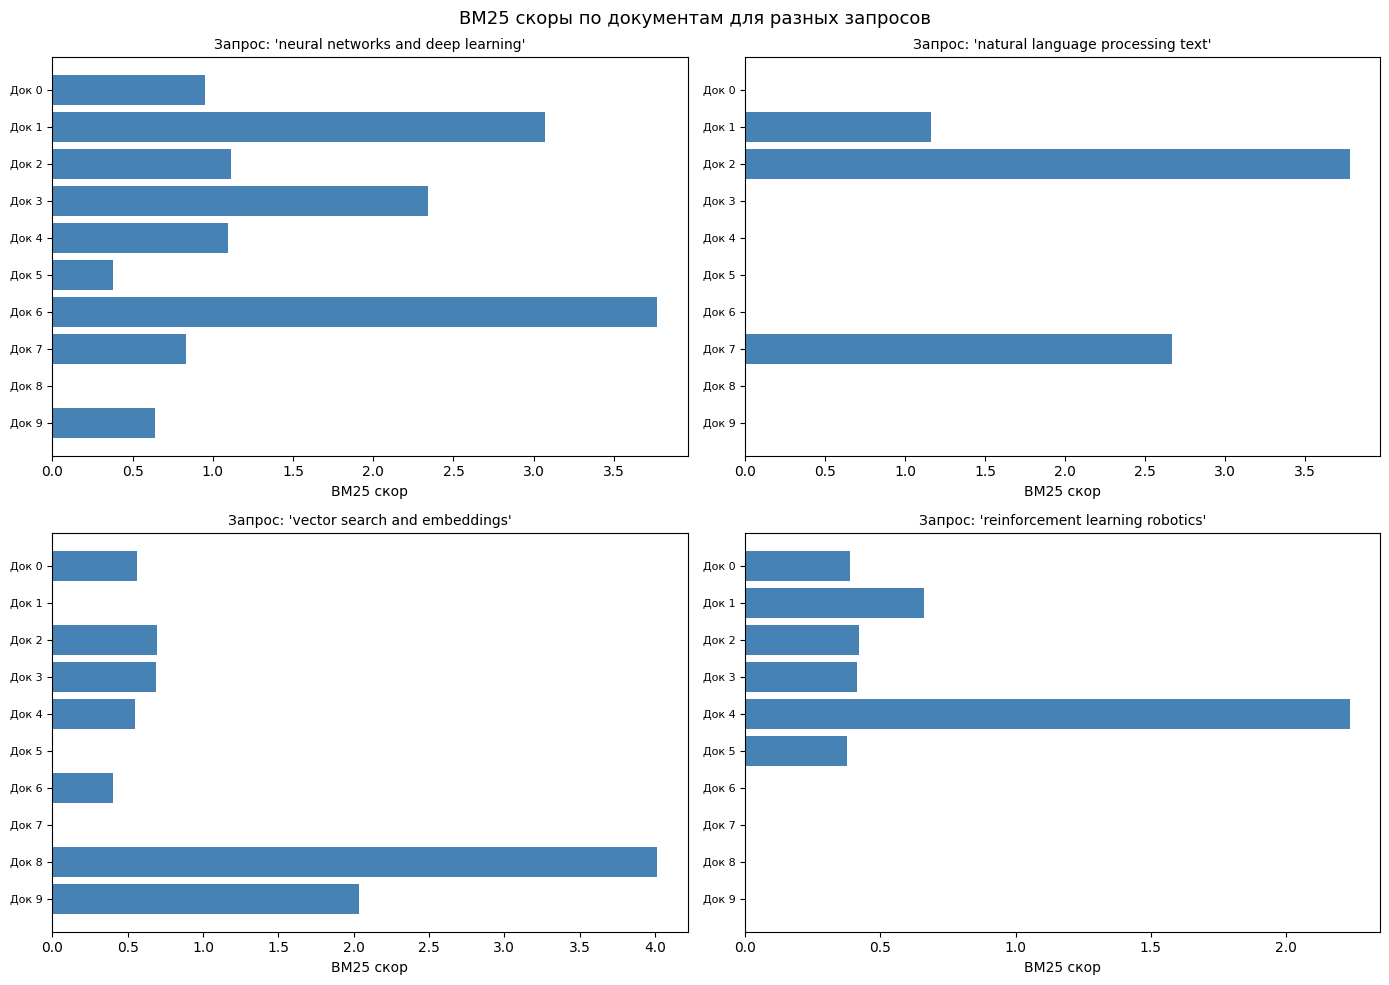

In [10]:
# Визуализация BM25 скоров для разных запросов
queries = [
    "neural networks and deep learning",
    "natural language processing text",
    "vector search and embeddings",
    "reinforcement learning robotics",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, query in zip(axes, queries):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)

    colors = ["steelblue" if s > 0 else "lightgray" for s in scores]
    ax.barh(range(len(scores)), scores, color=colors)
    ax.set_yticks(range(len(scores)))
    ax.set_yticklabels([f"Док {i}" for i in range(len(scores))], fontsize=8)
    ax.set_xlabel("BM25 скор")
    ax.set_title(f"Запрос: '{query}'", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("BM25 скоры по документам для разных запросов", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Плотные векторные представления (Dense Embeddings)

Модели эмбеддингов (например, sentence-transformers) преобразуют тексты
в плотные числовые векторы фиксированной размерности. Тексты с близким
смыслом получают близкие векторы.

Мы используем модель all-MiniLM-L6-v2:
- Размерность: 384
- Быстрая, работает на CPU
- Хорошее качество для английского языка

In [11]:
from sentence_transformers import SentenceTransformer

# Загрузка модели эмбеддингов
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Кодирование документов
doc_embeddings = embed_model.encode(documents, show_progress_bar=True)
print(f"Форма матрицы эмбеддингов: {doc_embeddings.shape}")
print(f"Размерность одного эмбеддинга: {doc_embeddings.shape[1]}")

c:\Users\anmrt\Desktop\Useful shit\nlp_labs_8sem\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6694.77it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 1/1 [00:00<00:00,  4.45it/s]

Форма матрицы эмбеддингов: (10, 384)
Размерность одного эмбеддинга: 384


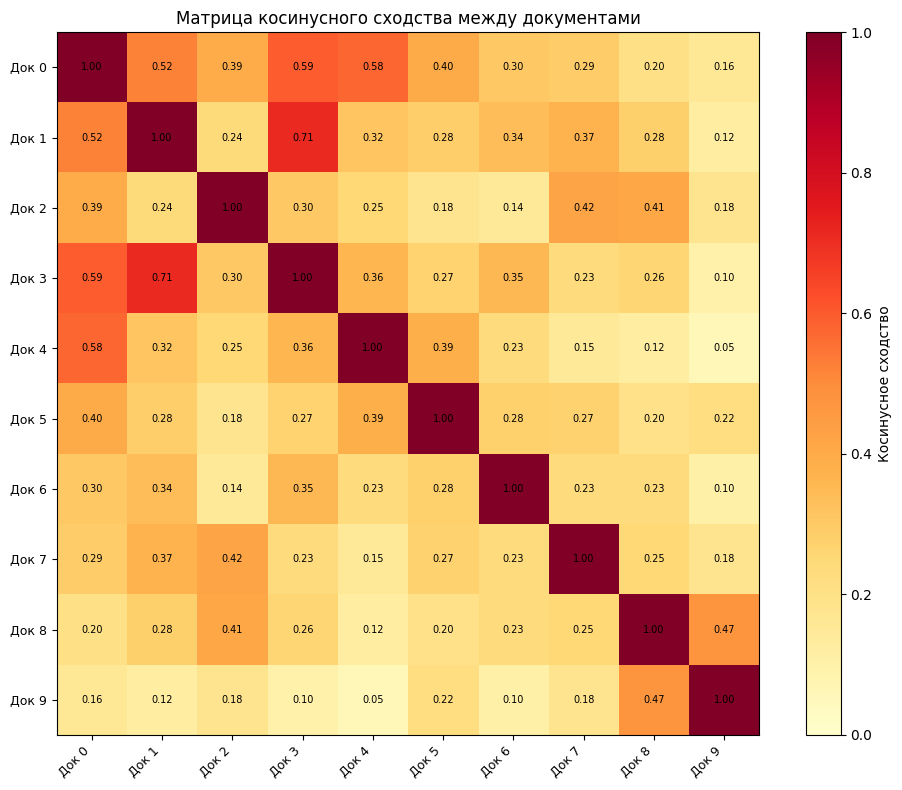

In [12]:
# Косинусное сходство между документами
from numpy.linalg import norm

def cosine_similarity(a, b):
    """Вычислить косинусное сходство между двумя векторами."""
    return np.dot(a, b) / (norm(a) * norm(b))


# Матрица сходства
n = len(documents)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(doc_embeddings[i], doc_embeddings[j])

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
short_labels = [f"Док {i}" for i in range(n)]
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_title("Матрица косинусного сходства между документами")

# Добавляем значения в ячейки
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, label="Косинусное сходство")
plt.tight_layout()
plt.show()

## 5. Визуализация эмбеддингов

Визуализируем 384-мерные эмбеддинги в 2D с помощью PCA
(метод главных компонент).

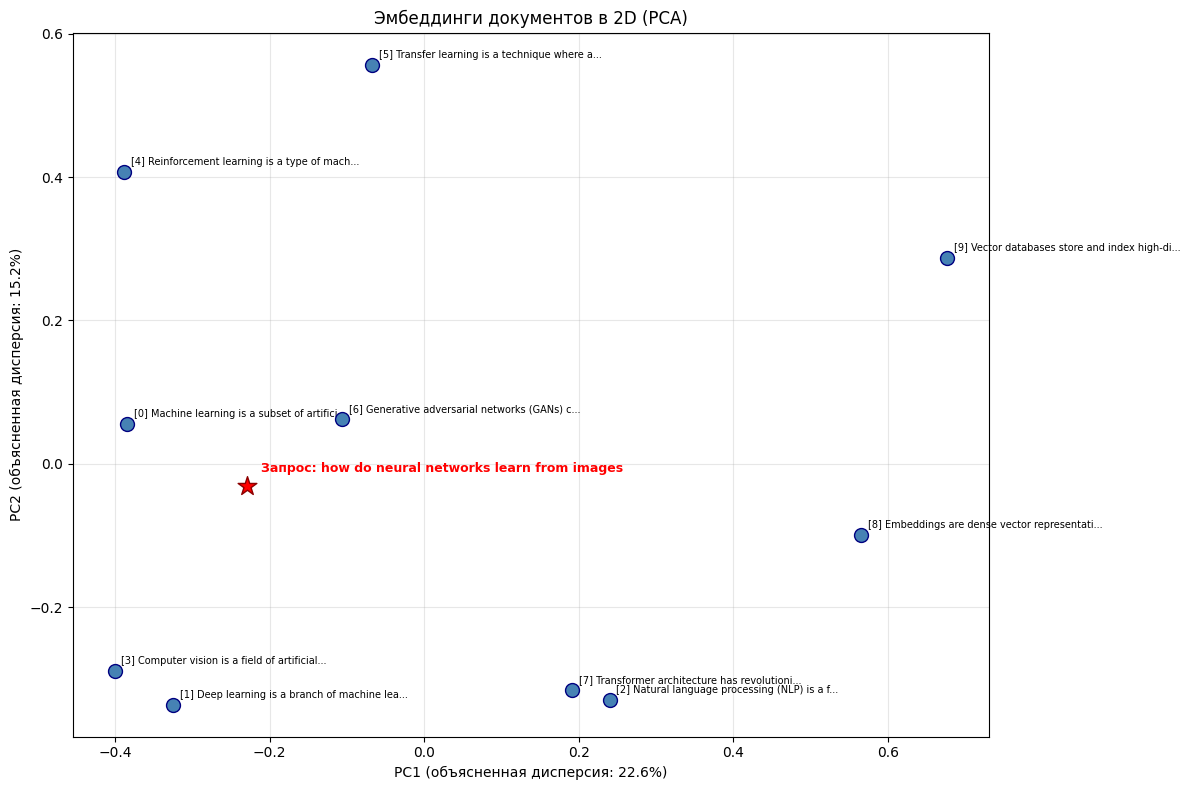

In [13]:
from sklearn.decomposition import PCA

# Уменьшение размерности до 2D
pca = PCA(n_components=2, random_state=SEED)
embeddings_2d = pca.fit_transform(doc_embeddings)

# Также кодируем запрос
query = "how do neural networks learn from images"
query_emb = embed_model.encode([query])
query_2d = pca.transform(query_emb)

fig, ax = plt.subplots(figsize=(12, 8))

# Документы
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                     s=100, c="steelblue", edgecolors="navy", zorder=5)

# Подписи документов
for i in range(len(documents)):
    short = documents[i][:40] + "..."
    ax.annotate(f"[{i}] {short}", (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")

# Запрос
ax.scatter(query_2d[:, 0], query_2d[:, 1],
           s=200, c="red", marker="*", edgecolors="darkred", zorder=10)
ax.annotate(f"Запрос: {query}", (query_2d[0, 0], query_2d[0, 1]),
            fontsize=9, color="red", xytext=(10, 10), textcoords="offset points",
            fontweight="bold")

ax.set_xlabel(f"PC1 (объясненная дисперсия: {pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 (объясненная дисперсия: {pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Эмбеддинги документов в 2D (PCA)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Векторный поиск с FAISS

FAISS (Facebook AI Similarity Search) -- библиотека для эффективного
поиска ближайших соседей в пространстве векторов.

Поддерживает различные типы индексов:
- **Flat**: точный поиск (перебор всех векторов).
- **IVF**: приближенный поиск с кластеризацией.
- **HNSW**: граф ближайших соседей.

Для небольших коллекций используем точный индекс (Flat).

In [14]:
# !pip install faiss-cpu

In [15]:
import faiss

# Создание индекса FAISS
dimension = doc_embeddings.shape[1]  # 384
index = faiss.IndexFlatIP(dimension)  # Inner Product (для нормализованных = cosine)

# Нормализация векторов для косинусного сходства
doc_emb_normalized = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
index.add(doc_emb_normalized.astype(np.float32))

print(f"Индекс FAISS создан. Количество векторов: {index.ntotal}")
print(f"Размерность: {dimension}")


def semantic_search(query, top_k=3):
    """Семантический поиск через FAISS."""
    query_emb = embed_model.encode([query])
    query_emb_norm = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)

    scores, indices = index.search(query_emb_norm.astype(np.float32), top_k)

    results = []
    for i in range(top_k):
        idx = int(indices[0][i])
        results.append({
            "index": idx,
            "score": float(scores[0][i]),
            "text": documents[idx]
        })
    return results


# Тестирование
query = "how do neural networks learn from images"
results = semantic_search(query, top_k=3)

print(f"\nЗапрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Сходство: {r['score']:.4f}")
    print(f"      {r['text'][:80]}...")
    print()

Индекс FAISS создан. Количество векторов: 10
Размерность: 384

Запрос: 'how do neural networks learn from images'

  [1] Сходство: 0.5977
      Deep learning is a branch of machine learning based on artificial neural network...

  [3] Сходство: 0.5760
      Computer vision is a field of artificial intelligence that trains computers to i...

  [6] Сходство: 0.4351
      Generative adversarial networks (GANs) consist of two neural networks that compe...



In [16]:
# Сравнение BM25 и семантического поиска
comparison_queries = [
    "systems that learn without explicit programming",  # перефразирование
    "generating realistic images with AI",              # семантическая близость
    "attention mechanism in transformers",              # терминология
]

print("=== Сравнение BM25 vs Семантический поиск ===")
print()

for query in comparison_queries:
    bm25_results, _ = bm25_search(query, top_k=3)
    sem_results = semantic_search(query, top_k=3)

    print(f"Запрос: '{query}'")
    print(f"  BM25 top-3: документы {[r['index'] for r in bm25_results]}")
    print(f"  Семантический top-3: документы {[r['index'] for r in sem_results]}")
    print()

=== Сравнение BM25 vs Семантический поиск ===

Запрос: 'systems that learn without explicit programming'
  BM25 top-3: документы [0, 3, 6]
  Семантический top-3: документы [0, 4, 5]

Запрос: 'generating realistic images with AI'
  BM25 top-3: документы [2, 3, 9]
  Семантический top-3: документы [3, 6, 1]

Запрос: 'attention mechanism in transformers'
  BM25 top-3: документы [4, 7, 8]
  Семантический top-3: документы [7, 5, 6]



## 7. Кросс-энкодер для переранжирования

Двухэтапная схема поиска:
1. **Bi-encoder** (быстрый): кодирует запрос и документы отдельно,
   находит кандидатов через FAISS.
2. **Cross-encoder** (точный): обрабатывает пару (запрос, документ)
   совместно, дает более точную оценку релевантности.

Кросс-энкодер медленнее, поэтому применяется только к небольшому
набору кандидатов (top-k из первого этапа).

In [17]:
from sentence_transformers import CrossEncoder

# Загрузка кросс-энкодера
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, candidate_docs, top_k=3):
    """Переранжирование документов кросс-энкодером."""
    pairs = [(query, doc) for doc in candidate_docs]
    scores = cross_encoder.predict(pairs)

    ranked_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for idx in ranked_indices:
        results.append({
            "original_index": idx,
            "score": float(scores[idx]),
            "text": candidate_docs[idx]
        })
    return results, scores


# Двухэтапный поиск
query = "how do machines understand human language"

# Этап 1: быстрый поиск (top-5 кандидатов)
stage1_results = semantic_search(query, top_k=5)
candidate_texts = [r["text"] for r in stage1_results]
candidate_indices = [r["index"] for r in stage1_results]

print(f"Запрос: '{query}'")
print()
print("Этап 1 -- Bi-encoder (FAISS):")
for r in stage1_results:
    print(f"  [{r['index']}] Сходство: {r['score']:.4f} -- {r['text'][:60]}...")
print()

# Этап 2: переранжирование (top-3)
stage2_results, ce_scores = rerank(query, candidate_texts, top_k=3)

print("Этап 2 -- Cross-encoder (переранжирование):")
for r in stage2_results:
    orig_doc_idx = candidate_indices[r["original_index"]]
    print(f"  [{orig_doc_idx}] Скор: {r['score']:.4f} -- {r['text'][:60]}...")

c:\Users\anmrt\Desktop\Useful shit\nlp_labs_8sem\venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anmrt\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 4227.76it/s]
BertForSe

Запрос: 'how do machines understand human language'

Этап 1 -- Bi-encoder (FAISS):
  [0] Сходство: 0.4363 -- Machine learning is a subset of artificial intelligence that...
  [2] Сходство: 0.4356 -- Natural language processing (NLP) is a field of computer sci...
  [3] Сходство: 0.4241 -- Computer vision is a field of artificial intelligence that t...
  [7] Сходство: 0.4023 -- Transformer architecture has revolutionized natural language...
  [1] Сходство: 0.3365 -- Deep learning is a branch of machine learning based on artif...

Этап 2 -- Cross-encoder (переранжирование):
  [2] Скор: 0.0316 -- Natural language processing (NLP) is a field of computer sci...
  [0] Скор: -2.2804 -- Machine learning is a subset of artificial intelligence that...
  [3] Скор: -4.1244 -- Computer vision is a field of artificial intelligence that t...


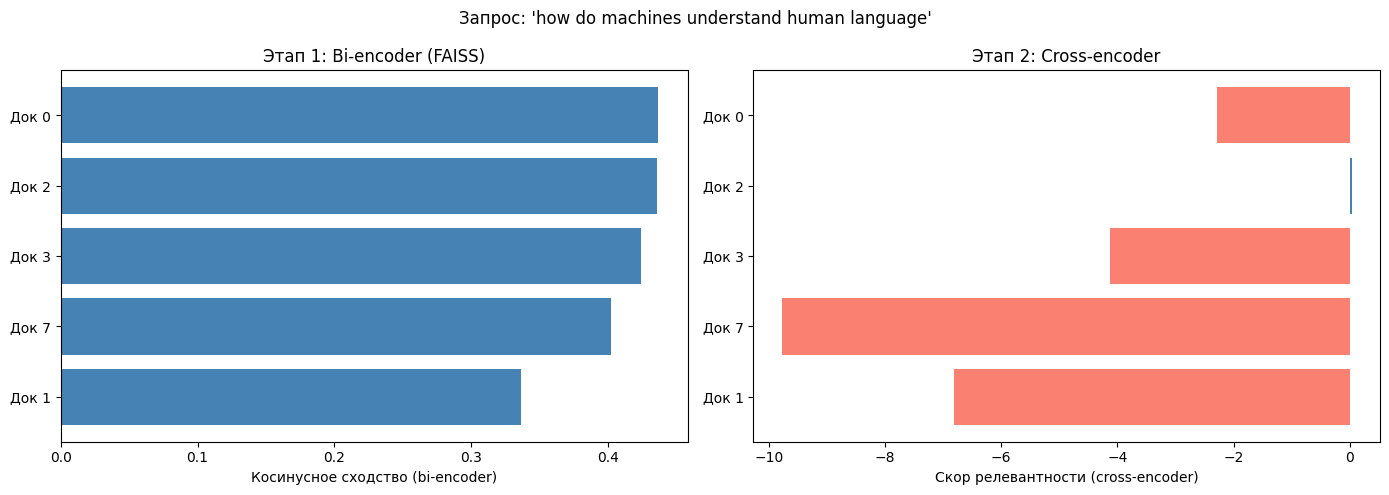

In [18]:
# Визуализация: сравнение скоров bi-encoder и cross-encoder
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bi-encoder скоры
bi_scores = [r["score"] for r in stage1_results]
bi_labels = [f"Док {r['index']}" for r in stage1_results]
axes[0].barh(bi_labels, bi_scores, color="steelblue")
axes[0].set_xlabel("Косинусное сходство (bi-encoder)")
axes[0].set_title("Этап 1: Bi-encoder (FAISS)")
axes[0].invert_yaxis()

# Cross-encoder скоры
ce_labels = [f"Док {candidate_indices[i]}" for i in range(len(ce_scores))]
ce_colors = ["steelblue" if s > 0 else "salmon" for s in ce_scores]
axes[1].barh(ce_labels, ce_scores, color=ce_colors)
axes[1].set_xlabel("Скор релевантности (cross-encoder)")
axes[1].set_title("Этап 2: Cross-encoder")
axes[1].invert_yaxis()

plt.suptitle(f"Запрос: '{query}'", fontsize=12)
plt.tight_layout()
plt.show()

## 8. RAG: поиск + генерация

RAG (Retrieval-Augmented Generation) объединяет:
1. **Retrieval**: поиск релевантных фрагментов из базы знаний.
2. **Augmented**: добавление найденных фрагментов в контекст промпта.
3. **Generation**: генерация ответа языковой моделью на основе контекста.

Преимущества RAG:
- Модель отвечает на основе актуальных данных, а не только обучающей выборки.
- Снижение галлюцинаций за счет привязки к источникам.
- Легко обновлять базу знаний без переобучения модели.

In [19]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Загрузка генеративной модели
gen_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gen_model = GPT2LMHeadModel.from_pretrained("gpt2")
gen_model.eval()

def generate_answer(prompt, max_new_tokens=80):
    """Генерация ответа с помощью GPT-2."""
    torch.manual_seed(SEED)
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = gen_model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=0.5,
            do_sample=True,
            pad_token_id=gen_tokenizer.eos_token_id,
            no_repeat_ngram_size=3
        )
    full_text = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full_text[len(prompt):].strip()


def simple_rag(query, top_k=3):
    """Простой RAG: поиск + генерация."""
    # Шаг 1: Поиск релевантных документов
    results = semantic_search(query, top_k=top_k)

    # Шаг 2: Формирование контекста
    context_parts = []
    for i, r in enumerate(results):
        context_parts.append(f"Source {i+1}: {r['text']}")
    context = "\n".join(context_parts)

    # Шаг 3: Формирование промпта для генерации
    rag_prompt = (
        f"Based on the following sources, answer the question.\n\n"
        f"{context}\n\n"
        f"Question: {query}\n"
        f"Answer:"
    )

    # Шаг 4: Генерация ответа
    answer = generate_answer(rag_prompt, max_new_tokens=60)

    return {
        "query": query,
        "sources": results,
        "answer": answer,
        "prompt": rag_prompt
    }


# Тестирование RAG
rag_result = simple_rag("What is transfer learning and why is it useful?")

print("=== RAG результат ===")
print(f"Запрос: {rag_result['query']}")
print()
print("Найденные источники:")
for src in rag_result["sources"]:
    print(f"  [{src['index']}] {src['text'][:80]}...")
print()
print(f"Ответ: {rag_result['answer']}")

c:\Users\anmrt\Desktop\Useful shit\nlp_labs_8sem\venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anmrt\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9413.40it/s]
The attention mask is not set and cannot b

=== RAG результат ===
Запрос: What is transfer learning and why is it useful?

Найденные источники:
  [5] Transfer learning is a technique where a model trained on one task is reused as ...
  [0] Machine learning is a subset of artificial intelligence that enables systems to ...
  [4] Reinforcement learning is a type of machine learning where an agent learns to ma...

Ответ: Transfer Learning is a tool that allows systems to train on a set of tasks and then learn to perform those tasks for themselves without the need for any other training data.
.
The goal of transfer learning is to train a system on a task and then apply this knowledge to learn new tasks.


## 9. Полноценный RAG-конвейер

Объединим все компоненты в один класс: разбиение на фрагменты,
индексация, поиск (гибридный: BM25 + FAISS), переранжирование
и генерация ответа.

In [20]:
class RAGPipeline:
    """Полноценный RAG-конвейер."""

    def __init__(self, embed_model_name="all-MiniLM-L6-v2"):
        self.embed_model = SentenceTransformer(embed_model_name)
        self.gen_tokenizer = gen_tokenizer
        self.gen_model = gen_model
        self.cross_encoder = cross_encoder
        self.documents = []
        self.chunks = []
        self.chunk_to_doc = []  # маппинг: индекс фрагмента -> индекс документа
        self.bm25 = None
        self.faiss_index = None
        self.chunk_embeddings = None

    def add_documents(self, docs, chunk_size=30, overlap=10):
        """Добавить документы в базу знаний."""
        self.documents = docs
        self.chunks = []
        self.chunk_to_doc = []

        for doc_idx, doc in enumerate(docs):
            doc_chunks = chunk_by_words(doc, chunk_size=chunk_size, overlap=overlap)
            for chunk in doc_chunks:
                self.chunks.append(chunk)
                self.chunk_to_doc.append(doc_idx)

        print(f"Документов: {len(docs)}")
        print(f"Фрагментов: {len(self.chunks)}")

        # Индексация BM25
        tokenized_chunks = [c.lower().split() for c in self.chunks]
        self.bm25 = BM25Okapi(tokenized_chunks)

        # Индексация FAISS
        self.chunk_embeddings = self.embed_model.encode(self.chunks)
        emb_norm = self.chunk_embeddings / np.linalg.norm(
            self.chunk_embeddings, axis=1, keepdims=True
        )
        self.faiss_index = faiss.IndexFlatIP(emb_norm.shape[1])
        self.faiss_index.add(emb_norm.astype(np.float32))

        print("Индексы BM25 и FAISS построены.")

    def hybrid_search(self, query, top_k=5, bm25_weight=0.3):
        """Гибридный поиск: BM25 + семантический."""
        # BM25 скоры
        bm25_scores = self.bm25.get_scores(query.lower().split())
        if bm25_scores.max() > 0:
            bm25_scores = bm25_scores / bm25_scores.max()

        # Семантические скоры
        query_emb = self.embed_model.encode([query])
        query_emb_norm = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)
        sem_scores, _ = self.faiss_index.search(
            query_emb_norm.astype(np.float32), len(self.chunks)
        )
        sem_scores_all = np.zeros(len(self.chunks))
        for i in range(len(self.chunks)):
            sim = cosine_similarity(query_emb_norm[0], self.chunk_embeddings[i] /
                                    np.linalg.norm(self.chunk_embeddings[i]))
            sem_scores_all[i] = sim

        # Комбинированный скор
        combined = bm25_weight * bm25_scores + (1 - bm25_weight) * sem_scores_all
        top_indices = np.argsort(combined)[::-1][:top_k]

        results = []
        for idx in top_indices:
            results.append({
                "chunk_index": int(idx),
                "doc_index": self.chunk_to_doc[idx],
                "score": float(combined[idx]),
                "text": self.chunks[idx]
            })
        return results

    def rerank(self, query, candidates, top_k=3):
        """Переранжирование кросс-энкодером."""
        pairs = [(query, c["text"]) for c in candidates]
        scores = self.cross_encoder.predict(pairs)

        ranked = sorted(
            zip(candidates, scores),
            key=lambda x: x[1],
            reverse=True
        )[:top_k]

        return [
            {**cand, "rerank_score": float(score)}
            for cand, score in ranked
        ]

    def generate(self, query, context_chunks, max_new_tokens=80):
        """Генерация ответа на основе контекста."""
        context = "\n".join([f"- {c['text']}" for c in context_chunks])
        prompt = (
            f"Based on the following information, answer the question.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}\n"
            f"Answer:"
        )

        torch.manual_seed(SEED)
        input_ids = self.gen_tokenizer.encode(prompt, return_tensors="pt")
        with torch.no_grad():
            outputs = self.gen_model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,
                temperature=0.5,
                do_sample=True,
                pad_token_id=self.gen_tokenizer.eos_token_id,
                no_repeat_ngram_size=3,
            )
        full = self.gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
        return full[len(prompt):].strip()

    def query(self, question, top_k_search=5, top_k_rerank=3, verbose=True):
        """Полный RAG-запрос."""
        if verbose:
            print(f"Вопрос: {question}")
            print()

        # Этап 1: Гибридный поиск
        candidates = self.hybrid_search(question, top_k=top_k_search)
        if verbose:
            print("Этап 1 -- Гибридный поиск (кандидаты):")
            for c in candidates:
                print(f"  [Док {c['doc_index']}] Скор: {c['score']:.3f} -- {c['text'][:60]}...")
            print()

        # Этап 2: Переранжирование
        reranked = self.rerank(question, candidates, top_k=top_k_rerank)
        if verbose:
            print("Этап 2 -- Переранжирование:")
            for c in reranked:
                print(f"  [Док {c['doc_index']}] Скор: {c['rerank_score']:.3f} -- {c['text'][:60]}...")
            print()

        # Этап 3: Генерация
        answer = self.generate(question, reranked)
        if verbose:
            print(f"Ответ: {answer}")

        return {
            "question": question,
            "candidates": candidates,
            "reranked": reranked,
            "answer": answer,
        }


# Создание и тестирование конвейера
rag = RAGPipeline()
rag.add_documents(documents)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8801.33it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Документов: 10
Фрагментов: 20
Индексы BM25 и FAISS построены.


In [21]:
# Запрос к RAG-конвейеру
print("=" * 70)
result = rag.query("What are the main approaches to understanding human language with AI?")
print()
print("=" * 70)
result2 = rag.query("How can pre-trained models be applied to new tasks?")

Вопрос: What are the main approaches to understanding human language with AI?

Этап 1 -- Гибридный поиск (кандидаты):
  [Док 2] Скор: 0.640 -- Natural language processing (NLP) is a field of computer sci...
  [Док 2] Скор: 0.435 -- language. NLP combines computational linguistics with statis...
  [Док 7] Скор: 0.376 -- Transformer architecture has revolutionized natural language...
  [Док 7] Скор: 0.277 -- training than previous recurrent neural network approaches....
  [Док 0] Скор: 0.268 -- programmed. It focuses on developing algorithms that can acc...

Этап 2 -- Переранжирование:
  [Док 2] Скор: -3.569 -- Natural language processing (NLP) is a field of computer sci...
  [Док 7] Скор: -5.738 -- Transformer architecture has revolutionized natural language...
  [Док 2] Скор: -6.207 -- language. NLP combines computational linguistics with statis...

Ответ: The main approaches are:

- AI is a method of learning and developing new knowledge.
. AI is an approach to understanding the human

## 10. Самостоятельные задания

---

### Задание 1. Сравнение стратегий разбиения на фрагменты

Проведите эксперимент:
1. Возьмите длинный текст (не менее 500 слов) и разбейте его тремя способами:
   - По фиксированному числу слов (chunk_size=20, overlap=5).
   - По фиксированному числу слов (chunk_size=50, overlap=10).
   - По предложениям.
2. Для каждого варианта создайте FAISS-индекс.
3. Выполните 5 тестовых запросов и сравните качество поиска (top-3 результаты).
4. Постройте таблицу с результатами и выводами.

Количество слов в длинном тексте: 993


,Стратегия,Количество_чанков,Средняя_длина_в_словах
0,words_20_5,67,19.72
1,words_50_10,25,49.32
2,sentences,66,15.05


,Стратегия,Средний_Hit@3
0,sentences,1.0
1,words_20_5,1.0
2,words_50_10,1.0


,Стратегия,Запрос,Hit@3,Top-3 индексы,Top-3 скоры,Top-1 текст
0,words_20_5,learning from experience without explicit prog...,1,"[1, 0, 23]","[0.576, 0.5718, 0.5706]",from experience without being explicitly progr...
1,words_20_5,image recognition with neural networks,1,"[25, 26, 30]","[0.5073, 0.4734, 0.4701]",learning based on artificial neural networks. ...
2,words_20_5,understanding human language with computers,1,"[28, 50, 6]","[0.634, 0.6288, 0.5268]",interactions between computers and human langu...
3,words_20_5,models reused for a new task with little data,1,"[13, 12, 57]","[0.6687, 0.6488, 0.6458]",for a model on a second task. This approach is...
4,words_20_5,semantic search with dense vectors,1,"[65, 20, 64]","[0.6344, 0.5656, 0.5422]",vectors for efficient similarity search. They ...
5,words_50_10,learning from experience without explicit prog...,1,"[3, 11, 20]","[0.4241, 0.4198, 0.4172]",the visual world. Using digital images and dee...
6,words_50_10,image recognition with neural networks,1,"[1, 9, 18]","[0.4962, 0.4217, 0.4093]",a branch of machine learning based on artifici...
7,words_50_10,understanding human language with computers,1,"[2, 10, 18]","[0.5452, 0.503, 0.4778]",field of computer science and linguistics conc...
8,words_50_10,models reused for a new task with little data,1,"[13, 12, 21]","[0.4014, 0.3534, 0.3327]",is reused as the starting point for a model on...
9,words_50_10,semantic search with dense vectors,1,"[24, 7, 15]","[0.629, 0.6248, 0.616]",have similar vector representations in a conti...


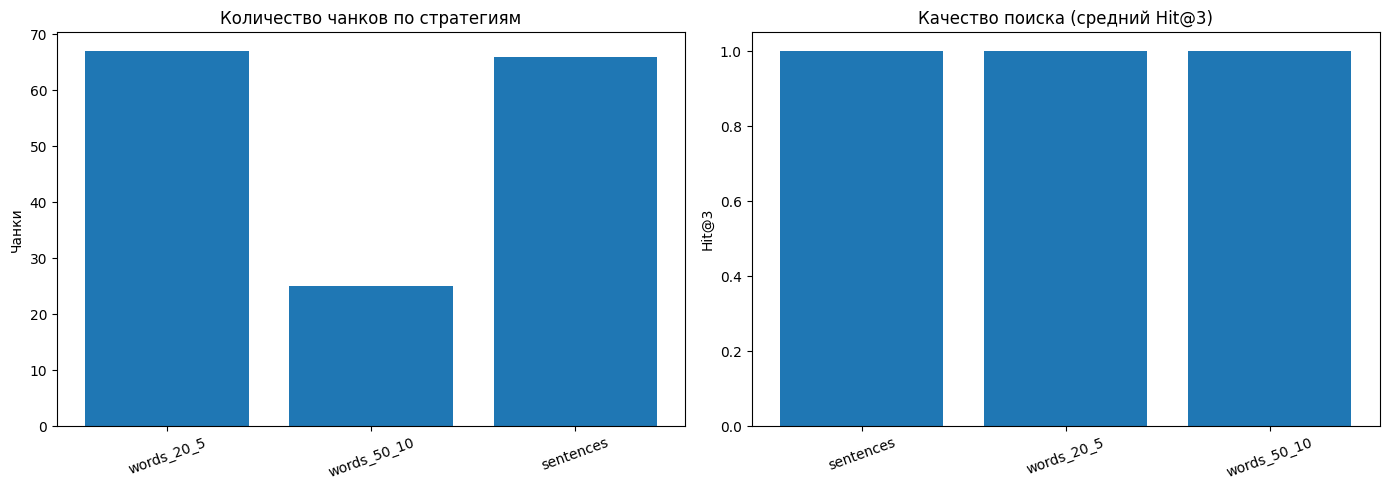

Стратегия: words_20_5 | чанков: 67
----------------------------------------------------------------------------------------------------
Запрос: learning from experience without explicit programming
  rank=1 | chunk=1 | score=0.5760
    from experience without being explicitly programmed. It focuses on developing algorithms that can access data and use it to learn
  rank=2 | chunk=0 | score=0.5718
    Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly
  rank=3 | chunk=23 | score=0.5706
    improve from experience without being explicitly programmed. It focuses on developing algorithms that can access data and use it to
  Hit@3: 1
----------------------------------------------------------------------------------------------------
Запрос: image recognition with neural networks
  rank=1 | chunk=25 | score=0.5073
    learning based on artificial neural networks. It uses multiple layers of processing to p

In [22]:
# Задание 1

import pandas as pd
from IPython.display import display

# Длинный текст (объединение тематическиих абзацев из корпуса несколько раз)
long_text = " ".join(documents * 3)
word_count = len(long_text.split())
print(f"Количество слов в длинном тексте: {word_count}")

# Три стратегии разбиения
chunking_strategies = {
    "words_20_5": chunk_by_words(long_text, chunk_size=20, overlap=5),
    "words_50_10": chunk_by_words(long_text, chunk_size=50, overlap=10),
    "sentences": chunk_by_sentences(long_text),
}

# Тестовые запросы и ожидаемые ключевые слова / темы в релевантных чанках
test_queries = [
    ("learning from experience without explicit programming", ["machine learning", "explicitly programmed"]),
    ("image recognition with neural networks", ["deep learning", "image recognition", "computer vision"]),
    ("understanding human language with computers", ["natural language processing", "human language", "transformer"]),
    ("models reused for a new task with little data", ["transfer learning", "second task", "limited training data"]),
    ("semantic search with dense vectors", ["embeddings", "vector databases", "semantic search"]),
]

def build_faiss_for_chunks(chunks):
#Построить FAISS-индекс для списка чанков
    emb = embed_model.encode(chunks, show_progress_bar=False)
    emb = emb.astype(np.float32)
    emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
    idx = faiss.IndexFlatIP(emb.shape[1])
    idx.add(emb_norm)
    return idx, emb_norm

def search_chunks_faiss(query, chunks, index, top_k=3):
#Семантический поиск по чанкам
    q = embed_model.encode([query], show_progress_bar=False).astype(np.float32)
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    scores, indices = index.search(q, top_k)
    return [
        {
            "rank": rank + 1,
            "chunk_index": int(chunk_idx),
            "score": float(scores[0][rank]),
            "text": chunks[int(chunk_idx)],
        }
        for rank, chunk_idx in enumerate(indices[0])
    ]

def hit_at_k(results, expected_patterns):
    joined = " || ".join(r["text"].lower() for r in results)
    return int(any(pattern.lower() in joined for pattern in expected_patterns))

# Индексация для всех стратегий
strategy_data = {}
summary_rows = []
search_rows = []

for strategy_name, chunks in chunking_strategies.items():
    index, embeddings = build_faiss_for_chunks(chunks)
    strategy_data[strategy_name] = {"chunks": chunks, "index": index, "embeddings": embeddings}

    avg_words = np.mean([len(c.split()) for c in chunks])
    summary_rows.append({
        "Стратегия": strategy_name,
        "Количество_чанков": len(chunks),
        "Средняя_длина_в_словах": round(float(avg_words), 2),
    })

    for query, expected_patterns in test_queries:
        results = search_chunks_faiss(query, chunks, index, top_k=3)
        search_rows.append({
            "Стратегия": strategy_name,
            "Запрос": query,
            "Hit@3": hit_at_k(results, expected_patterns),
            "Top-3 индексы": [r["chunk_index"] for r in results],
            "Top-3 скоры": [round(r["score"], 4) for r in results],
            "Top-1 текст": results[0]["text"][:120] + "...",
        })

summary_df = pd.DataFrame(summary_rows)
results_df = pd.DataFrame(search_rows)

# Сводная таблица качества
quality_df = (
    results_df.groupby("Стратегия", as_index=False)["Hit@3"]
    .mean()
    .rename(columns={"Hit@3": "Средний_Hit@3"})
    .sort_values("Средний_Hit@3", ascending=False)
)

display(summary_df)
display(quality_df)
display(results_df)

# Визуализация: сравнение количества чанков и качества
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df["Стратегия"], summary_df["Количество_чанков"])
axes[0].set_title("Количество чанков по стратегиям")
axes[0].set_ylabel("Чанки")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(quality_df["Стратегия"], quality_df["Средний_Hit@3"])
axes[1].set_title("Качество поиска (средний Hit@3)")
axes[1].set_ylabel("Hit@3")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Топ-3 результатов для каждого запроса и каждой стратегии
for strategy_name, chunks in chunking_strategies.items():
    print("=" * 100)
    print(f"Стратегия: {strategy_name} | чанков: {len(chunks)}")
    for query, expected_patterns in test_queries:
        print("-" * 100)
        print(f"Запрос: {query}")
        results = search_chunks_faiss(query, chunks, strategy_data[strategy_name]["index"], top_k=3)
        for r in results:
            print(f"  rank={r['rank']} | chunk={r['chunk_index']} | score={r['score']:.4f}")
            print(f"    {r['text']}")
        print(f"  Hit@3: {hit_at_k(results, expected_patterns)}")
    print()

best_strategy = quality_df.iloc[0]["Стратегия"]
print("Вывод:")
print(
    f"Лучший средний Hit@3 показала стратегия '{best_strategy}'. "
    "Мелкие чанки обычно дают более точное попадание в тему запроса, "
    "но слишком сильная фрагментация может терять контекст. "
    "Крупные чанки лучше сохраняют контекст, но иногда подмешивают лишнюю информацию. "
    "Разбиение по предложениям удобно интерпретировать, но оно чувствительно к длине и структуре предложений."
)

### Задание 2. Гибридный поиск с разными весами

Исследуйте влияние параметра bm25_weight в гибридном поиске:
1. Для 3 разных запросов выполните гибридный поиск с весами BM25:
   0.0, 0.2, 0.4, 0.6, 0.8, 1.0.
2. Для каждой комбинации запроса и веса запишите top-3 результата.
3. Постройте визуализацию (heatmap или таблицу), показывающую,
   как меняется состав top-3 при разных весах.
4. Сделайте выводы: при каких запросах лучше работает BM25,
   а при каких -- семантический поиск.

,Запрос,BM25_weight,Top-3 документы,Top-3 фрагменты,Top-3 скоры
0,self-attention in language models,0.0,"[7, 7, 5]","[14, 15, 11]","[0.5327, 0.3911, 0.3059]"
1,self-attention in language models,0.2,"[7, 7, 2]","[14, 15, 4]","[0.6262, 0.3128, 0.2708]"
2,self-attention in language models,0.4,"[7, 2, 7]","[14, 4, 15]","[0.7196, 0.2913, 0.2346]"
3,self-attention in language models,0.6,"[7, 2, 8]","[14, 4, 16]","[0.8131, 0.3118, 0.1857]"
4,self-attention in language models,0.8,"[7, 2, 8]","[14, 4, 17]","[0.9065, 0.3323, 0.1944]"
5,self-attention in language models,1.0,"[7, 2, 8]","[14, 4, 17]","[1.0, 0.3528, 0.2204]"
6,learning from rewards in robotics,0.0,"[4, 4, 5]","[8, 9, 10]","[0.5934, 0.4776, 0.3989]"
7,learning from rewards in robotics,0.2,"[4, 4, 1]","[8, 9, 3]","[0.5389, 0.4397, 0.426]"
8,learning from rewards in robotics,0.4,"[1, 4, 0]","[3, 8, 0]","[0.5695, 0.4843, 0.4132]"
9,learning from rewards in robotics,0.6,"[1, 0, 1]","[3, 0, 2]","[0.713, 0.4523, 0.4336]"


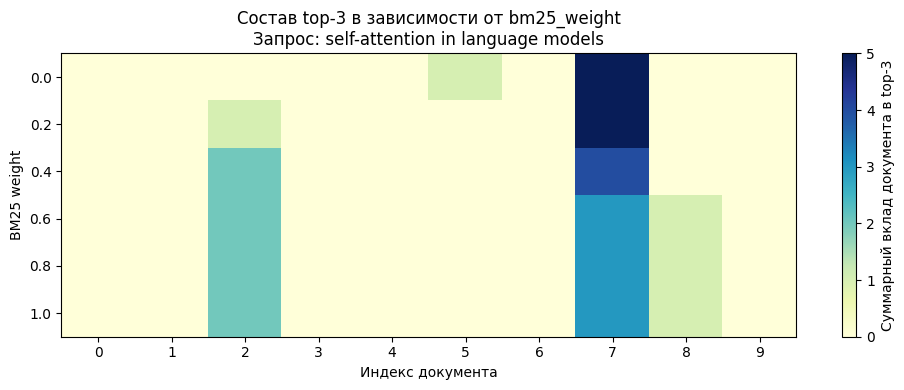

Документ,0,1,2,3,4,5,6,7,8,9
BM25_weight,,,,,,,,,,
0.0,0,0,0,0,0,1,0,5,0,0
0.2,0,0,1,0,0,0,0,5,0,0
0.4,0,0,2,0,0,0,0,4,0,0
0.6,0,0,2,0,0,0,0,3,1,0
0.8,0,0,2,0,0,0,0,3,1,0
1.0,0,0,2,0,0,0,0,3,1,0


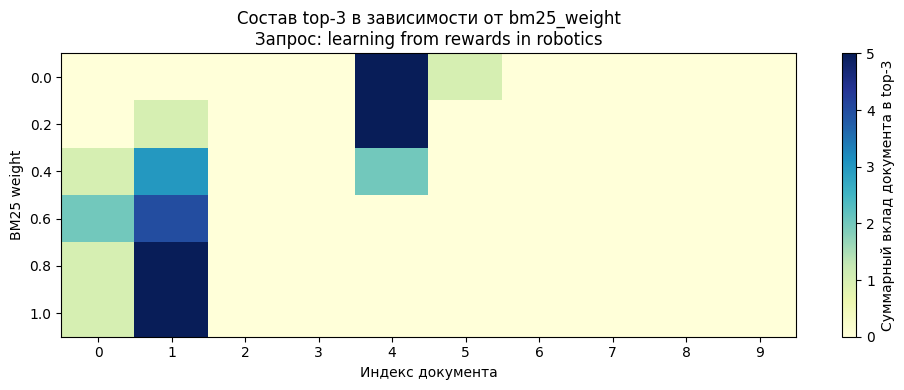

Документ,0,1,2,3,4,5,6,7,8,9
BM25_weight,,,,,,,,,,
0.0,0,0,0,0,5,1,0,0,0,0
0.2,0,1,0,0,5,0,0,0,0,0
0.4,1,3,0,0,2,0,0,0,0,0
0.6,2,4,0,0,0,0,0,0,0,0
0.8,1,5,0,0,0,0,0,0,0,0
1.0,1,5,0,0,0,0,0,0,0,0


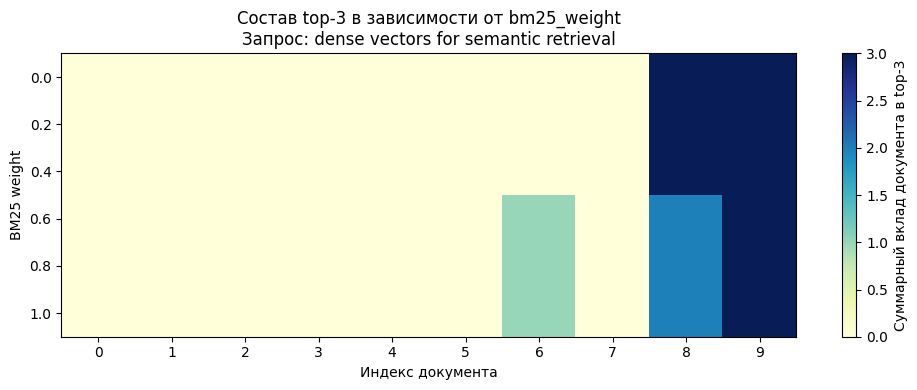

Документ,0,1,2,3,4,5,6,7,8,9
BM25_weight,,,,,,,,,,
0.0,0,0,0,0,0,0,0,0,3,3
0.2,0,0,0,0,0,0,0,0,3,3
0.4,0,0,0,0,0,0,0,0,3,3
0.6,0,0,0,0,0,0,1,0,2,3
0.8,0,0,0,0,0,0,1,0,2,3
1.0,0,0,0,0,0,0,1,0,2,3


Выводы по запросам:
----------------------------------------------------------------------------------------------------
Запрос: self-attention in language models
  При bm25_weight=0.0 (чистая семантика): [7, 7, 5]
  При bm25_weight=1.0 (чистый BM25):      [7, 2, 8]
  Интерпретация: состав выдачи меняется, значит лексический и семантический сигналы конкурируют.
----------------------------------------------------------------------------------------------------
Запрос: learning from rewards in robotics
  При bm25_weight=0.0 (чистая семантика): [4, 4, 5]
  При bm25_weight=1.0 (чистый BM25):      [1, 1, 0]
  Интерпретация: состав выдачи меняется, значит лексический и семантический сигналы конкурируют.
----------------------------------------------------------------------------------------------------
Запрос: dense vectors for semantic retrieval
  При bm25_weight=0.0 (чистая семантика): [9, 8, 8]
  При bm25_weight=1.0 (чистый BM25):      [9, 8, 6]
  Интерпретация: состав выдачи меняется, з

In [23]:
# Задание 2

import pandas as pd
from IPython.display import display

# Возьмем уже построенный конвейер rag
weights = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
hybrid_queries = [
    "self-attention in language models",
    "learning from rewards in robotics",
    "dense vectors for semantic retrieval",
]

top3_rows = []
heatmap_rows = []

for query in hybrid_queries:
    for weight in weights:
        results = rag.hybrid_search(query, top_k=3, bm25_weight=weight)
        doc_ids = [r["doc_index"] for r in results]
        top3_rows.append({
            "Запрос": query,
            "BM25_weight": weight,
            "Top-3 документы": doc_ids,
            "Top-3 фрагменты": [r["chunk_index"] for r in results],
            "Top-3 скоры": [round(r["score"], 4) for r in results],
        })
        for rank, item in enumerate(results, start=1):
            heatmap_rows.append({
                "Запрос": query,
                "BM25_weight": weight,
                "Документ": item["doc_index"],
                "Вклад_в_матрицу": 4 - rank,  # rank1 -> 3, rank2 -> 2, rank3 -> 1
            })

top3_df = pd.DataFrame(top3_rows)
display(top3_df)

# Матрица визуализации по каждому запросу
all_doc_ids = sorted(set(rag.chunk_to_doc))

for query in hybrid_queries:
    query_df = pd.DataFrame(heatmap_rows)
    query_df = query_df[query_df["Запрос"] == query]

    pivot = (
        query_df.pivot_table(
            index="BM25_weight",
            columns="Документ",
            values="Вклад_в_матрицу",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=weights, fill_value=0)
        .reindex(columns=all_doc_ids, fill_value=0)
    )

    plt.figure(figsize=(10, 4))
    plt.imshow(pivot.values, aspect="auto", cmap="YlGnBu")
    plt.title(f"Состав top-3 в зависимости от bm25_weight\nЗапрос: {query}")
    plt.xlabel("Индекс документа")
    plt.ylabel("BM25 weight")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    cbar = plt.colorbar()
    cbar.set_label("Суммарный вклад документа в top-3")
    plt.tight_layout()
    plt.show()

    display(pivot)

# Автоматические краткие выводы по каждому запросу
print("Выводы по запросам:")
for query in hybrid_queries:
    subset = top3_df[top3_df["Запрос"] == query]
    top_at_semantic = subset[subset["BM25_weight"] == 0.0]["Top-3 документы"].iloc[0]
    top_at_lexical = subset[subset["BM25_weight"] == 1.0]["Top-3 документы"].iloc[0]
    print("-" * 100)
    print(f"Запрос: {query}")
    print(f"  При bm25_weight=0.0 (чистая семантика): {top_at_semantic}")
    print(f"  При bm25_weight=1.0 (чистый BM25):      {top_at_lexical}")

    if top_at_semantic == top_at_lexical:
        print("  Интерпретация: запрос устойчив, и обе стратегии находят похожие документы.")
    else:
        print("  Интерпретация: состав выдачи меняется, значит лексический и семантический сигналы конкурируют.")

print()
print("Общий вывод:")
print(
    "BM25 обычно лучше работает на запросах с точными терминами и редкими ключевыми словами "
    "(например, 'self-attention'). Семантический поиск лучше справляется с перефразированием "
    "и описанием смысла без точного совпадения слов. Гибридный режим полезен, когда запросы "
    "содержат и терминологию, и семантический контекст."
)

### Задание 3. Расширение RAG-конвейера

Расширьте класс RAGPipeline:
1. Добавьте метод add_new_documents(), позволяющий добавлять документы
   в уже существующий индекс без полной переиндексации.
2. Добавьте метод evaluate(), который принимает список пар
   (вопрос, ожидаемый_документ) и вычисляет метрики:
   - Recall@k: доля случаев, когда правильный документ попал в top-k.
   - MRR (Mean Reciprocal Rank): средний обратный ранг правильного документа.
3. Протестируйте на 5 парах вопрос-документ.

In [ ]:
# Задание 3

import math
import pandas as pd
from collections import Counter
from IPython.display import display

class ExtendedRAGPipeline(RAGPipeline):
#Расширенный RAGPipeline с инкрементальным добавлением документов и оценкой качества

    def __init__(self, embed_model_name="all-MiniLM-L6-v2", k1=1.5, b=0.75):
        super().__init__(embed_model_name=embed_model_name)
        self.k1 = k1
        self.b = b
        self.tokenized_chunks = []
        self.doc_freqs = Counter()
        self.term_freqs = []
        self.doc_lengths = []
        self.avgdl = 0.0

    @staticmethod
    def _tokenize(text):
        return text.lower().split()

    def _reset_bm25_stats(self):
        self.tokenized_chunks = []
        self.doc_freqs = Counter()
        self.term_freqs = []
        self.doc_lengths = []
        self.avgdl = 0.0

    def _update_bm25_stats(self, new_chunks):
# Инкрементально обновить статистики BM25 только для новых чанков
        for chunk in new_chunks:
            tokens = self._tokenize(chunk)
            tf = Counter(tokens)
            self.tokenized_chunks.append(tokens)
            self.term_freqs.append(tf)
            self.doc_lengths.append(len(tokens))
            for term in tf.keys():
                self.doc_freqs[term] += 1
        self.avgdl = float(np.mean(self.doc_lengths)) if self.doc_lengths else 0.0

    def _bm25_scores(self, query):
# Собственная реализация BM25, поддерживающая инкрементальное обновление
        if not self.term_freqs:
            return np.array([])

        query_terms = self._tokenize(query)
        N = len(self.term_freqs)
        scores = np.zeros(N, dtype=np.float32)

        for i, tf in enumerate(self.term_freqs):
            dl = self.doc_lengths[i]
            score = 0.0
            for term in query_terms:
                if term not in tf:
                    continue
                df = self.doc_freqs.get(term, 0)
                idf = math.log(1.0 + (N - df + 0.5) / (df + 0.5))
                freq = tf[term]
                denom = freq + self.k1 * (1 - self.b + self.b * dl / max(self.avgdl, 1e-9))
                score += idf * (freq * (self.k1 + 1)) / denom
            scores[i] = score
        return scores

    def add_documents(self, docs, chunk_size=30, overlap=10):
        # Полная инициализация базы знаний
        self.documents = []
        self.chunks = []
        self.chunk_to_doc = []
        self.faiss_index = None
        self.chunk_embeddings = None
        self._reset_bm25_stats()
        self.add_new_documents(docs, chunk_size=chunk_size, overlap=overlap, verbose=True)

    def add_new_documents(self, new_docs, chunk_size=30, overlap=10, verbose=True):
        # Добавить новые документы без полной переиндексации:
        # BM25 статистики обновляются только по новым чанкам.
        # В FAISS добавляются только эмбеддинги новых чанков.
        start_doc_idx = len(self.documents)
        self.documents.extend(new_docs)

        new_chunks = []
        new_mapping = []
        for local_doc_idx, doc in enumerate(new_docs):
            global_doc_idx = start_doc_idx + local_doc_idx
            doc_chunks = chunk_by_words(doc, chunk_size=chunk_size, overlap=overlap)
            for chunk in doc_chunks:
                new_chunks.append(chunk)
                new_mapping.append(global_doc_idx)

        # Обновление текстовых структур
        self.chunks.extend(new_chunks)
        self.chunk_to_doc.extend(new_mapping)
        self._update_bm25_stats(new_chunks)

        # Эмбеддинги только для новых чанков
        if new_chunks:
            new_emb = self.embed_model.encode(new_chunks, show_progress_bar=False).astype(np.float32)
            new_emb_norm = new_emb / np.linalg.norm(new_emb, axis=1, keepdims=True)

            if self.chunk_embeddings is None:
                self.chunk_embeddings = new_emb
            else:
                self.chunk_embeddings = np.vstack([self.chunk_embeddings, new_emb])

            if self.faiss_index is None:
                self.faiss_index = faiss.IndexFlatIP(new_emb.shape[1])
            self.faiss_index.add(new_emb_norm)

        if verbose:
            print(f"Добавлено новых документов: {len(new_docs)}")
            print(f"Всего документов: {len(self.documents)}")
            print(f"Всего фрагментов: {len(self.chunks)}")

    def hybrid_search(self, query, top_k=5, bm25_weight=0.3):
        """Гибридный поиск с собственной инкрементальной BM25."""
        if not self.chunks:
            return []

        bm25_scores = self._bm25_scores(query)
        if bm25_scores.size and bm25_scores.max() > 0:
            bm25_scores = bm25_scores / bm25_scores.max()

        query_emb = self.embed_model.encode([query], show_progress_bar=False).astype(np.float32)
        query_emb_norm = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)

        chunk_embeddings_norm = self.chunk_embeddings / np.linalg.norm(
            self.chunk_embeddings, axis=1, keepdims=True
        )
        sem_scores = chunk_embeddings_norm @ query_emb_norm[0]
        sem_scores = sem_scores.astype(np.float32)

        combined = bm25_weight * bm25_scores + (1.0 - bm25_weight) * sem_scores
        top_indices = np.argsort(combined)[::-1][:top_k]

        return [
            {
                "chunk_index": int(idx),
                "doc_index": int(self.chunk_to_doc[idx]),
                "score": float(combined[idx]),
                "text": self.chunks[idx],
            }
            for idx in top_indices
        ]

    def evaluate(self, qa_pairs, k=3, bm25_weight=0.3):
        # Оценка качества retrieval:
        # qa_pairs: список пар (question, expected_document),
        # где expected_document может быть индексом документа или его текстом.
        rows = []
        reciprocal_ranks = []
        recall_hits = []

        for question, expected_doc in qa_pairs:
            if isinstance(expected_doc, str):
                try:
                    expected_idx = self.documents.index(expected_doc)
                except ValueError:
                    raise ValueError("Ожидаемый документ-строка не найден в self.documents")
            else:
                expected_idx = int(expected_doc)

            results = self.hybrid_search(question, top_k=max(k, 10), bm25_weight=bm25_weight)

            ranked_docs = []
            for item in results:
                if item["doc_index"] not in ranked_docs:
                    ranked_docs.append(item["doc_index"])
                if len(ranked_docs) >= k:
                    break

            hit = int(expected_idx in ranked_docs)
            recall_hits.append(hit)

            if expected_idx in ranked_docs:
                rank = ranked_docs.index(expected_idx) + 1
                rr = 1.0 / rank
            else:
                rank = None
                rr = 0.0
            reciprocal_ranks.append(rr)

            rows.append({
                "Вопрос": question,
                "Ожидаемый_документ": expected_idx,
                "Top-k документы": ranked_docs,
                "Hit@k": hit,
                "Ранг": rank,
                "Reciprocal Rank": rr,
            })

        details_df = pd.DataFrame(rows)
        metrics = {
            f"Recall@{k}": float(np.mean(recall_hits)),
            "MRR": float(np.mean(reciprocal_ranks)),
        }
        return metrics, details_df

# 1) Создание нового расширенного конвейера
extended_rag = ExtendedRAGPipeline()

# 2) Сначала индексируется только часть документов
base_docs = documents[:7]
new_docs = documents[7:]

print("Инициализация по базовым документам:")
extended_rag.add_documents(base_docs, chunk_size=30, overlap=10)

print("\nИнкрементальное добавление новых документов:")
extended_rag.add_new_documents(new_docs, chunk_size=30, overlap=10)

# 3) Проверка, что новые документы доступны в поиске
check_queries = [
    "self-attention for processing language in parallel",
    "dense vector representations for semantic similarity",
    "similarity search in vector databases",
]

for q in check_queries:
    print("\n" + "=" * 100)
    print(f"Проверочный запрос: {q}")
    for item in extended_rag.hybrid_search(q, top_k=3, bm25_weight=0.3):
        print(f"[Док {item['doc_index']}] score={item['score']:.4f} | {item['text'][:100]}...")

# 4) Оценка на 5 парах вопрос-документ
qa_pairs = [
    ("Which field studies interactions between computers and human language?", 2),
    ("What learning setup uses rewards from the environment?", 4),
    ("Which method reuses a model trained on one task for another task?", 5),
    ("Which architecture relies on self-attention and parallel processing?", 7),
    ("What stores high-dimensional vectors for similarity search?", 9),
]

metrics, eval_df = extended_rag.evaluate(qa_pairs, k=3, bm25_weight=0.3)

print("\nМетрики качества:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

display(eval_df)

print("\nВывод:")
print(
    "Метод add_new_documents() действительно добавляет новые документы инкрементально: "
    "новые чанки отдельно кодируются и дозаписываются в FAISS, а BM25-статистики обновляются "
    "только для новых чанков. Метод evaluate() позволяет быстро измерять качество retrieval "
    "через Recall@k и MRR."
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4881.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Инициализация по базовым документам:
Добавлено новых документов: 7
Всего документов: 7
Всего фрагментов: 14

Инкрементальное добавление новых документов:
Добавлено новых документов: 3
Всего документов: 10
Всего фрагментов: 20

Проверочный запрос: self-attention for processing language in parallel
[Док 7] score=0.7602 | Transformer architecture has revolutionized natural language processing. It uses self-attention mech...
[Док 2] score=0.4346 | Natural language processing (NLP) is a field of computer science and linguistics concerned with the ...
[Док 0] score=0.2994 | programmed. It focuses on developing algorithms that can access data and use it to learn for themsel...

Проверочный запрос: dense vector representations for semantic similarity
[Док 8] score=0.7571 | Embeddings are dense vector representations of data such as words, sentences, or documents. They cap...
[Док 9] score=0.6785 | Vector databases store and index high-dimensional vectors for efficient similarity search. They a

,Вопрос,Ожидаемый_документ,Top-k документы,Hit@k,Ранг,Reciprocal Rank
0,Which field studies interactions between compu...,2,"[2, 3, 0]",1,1,1.0
1,What learning setup uses rewards from the envi...,4,"[4, 1, 5]",1,1,1.0
2,Which method reuses a model trained on one tas...,5,"[5, 7, 4]",1,1,1.0
3,Which architecture relies on self-attention an...,7,"[7, 0, 5]",1,1,1.0
4,What stores high-dimensional vectors for simil...,9,"[9, 8, 5]",1,1,1.0



Вывод:
Метод add_new_documents() действительно добавляет новые документы инкрементально: новые чанки отдельно кодируются и дозаписываются в FAISS, а BM25-статистики обновляются только для новых чанков. Метод evaluate() позволяет быстро измерять качество retrieval через Recall@k и MRR.


---

8. Семантический поиск и RAG.